Logistic Regression Accuracy: 0.8070
Random Forest Accuracy: 0.9850
KNN Accuracy: 0.8120


C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_31208\3996811955.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), palette='magma')


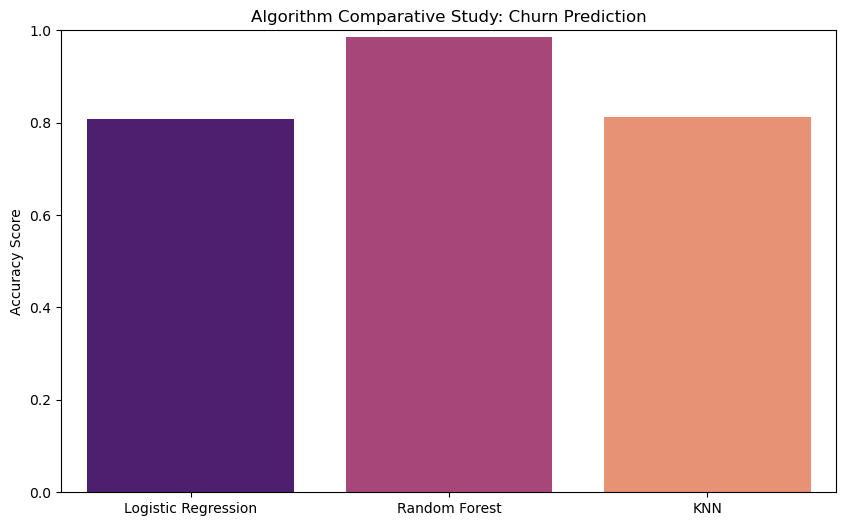


--- Random Forest Detailed Metrics ---
Precision: 1.000
Recall:    0.967
F1-Score:  0.983
Confusion matrix saved as 'confusion_matrix.png'


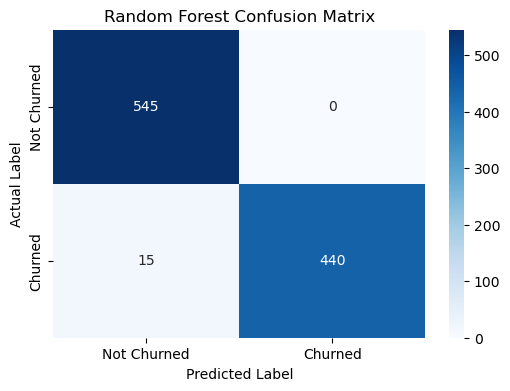

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

# 1. Load the Dataset
# Replace 'customer_data.csv' with your actual filename
df = pd.read_csv('Streaming_dataset.csv')

# 2. Data Cleaning & Preprocessing
# Handling missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Satisfaction_Score'] = df['Satisfaction_Score'].fillna(df['Satisfaction_Score'].mean())

# Encoding Categorical Variables (Gender, Region, Payment_Method)
df_encoded = pd.get_dummies(df, columns=['Gender', 'Region', 'Payment_Method'], drop_first=True)

# Defining Features (X) and Target (y)
X = df_encoded.drop(['Customer_ID', 'Churned'], axis=1)
y = df_encoded['Churned']

# Splitting Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling (Crucial for KNN and Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Algorithm Implementation & Comparison
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = {}

for name, model in models.items():
    # Use scaled data for LogReg and KNN
    if name == "Random Forest":
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

# 4. Visualization for Webpage
plt.figure(figsize=(10, 6))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='magma')
plt.title('Algorithm Comparative Study: Churn Prediction')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1.0)
plt.savefig('comparison_graph.png') # For your frontend
plt.show()

# 5. ADVANCED EVALUATION (For Chapter 5.2 & 5.3)
# Extracting the winning model (Random Forest) for detailed analysis
rf_model = models["Random Forest"]
y_pred_rf = rf_model.predict(X_test)

# Calculating Precision, Recall, and F1
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)

print(f"\n--- Random Forest Detailed Metrics ---")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-Score:  {f1:.3f}")

# 6. CONFUSION MATRIX VISUALIZATION
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Churned', 'Churned'], 
            yticklabels=['Not Churned', 'Churned'])
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.savefig('confusion_matrix.png', bbox_inches='tight')
print("Confusion matrix saved as 'confusion_matrix.png'")